## Task 3 – Dataset Understanding and Descriptive Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")

In [2]:
df_raw = pd.read_csv("freMTPL2freq.csv")
df = df_raw.copy()

### 3.1 Dataset Description

The data contain motor insurance policy observations. `ClaimNb` gives the number of claims and `Exposure` gives the amount of insurance exposure. The aim here is to understand the data and describe patterns linked with claim frequency.

In [3]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])
display(df.head())
df.info()

Number of observations: 678013
Number of variables: 12


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 70.4 MB


### 3.2 Variable Description

| Variable | Data Type | Statistical Type | Role | Meaning |
|---|---|---|---|---|
| IDpol | Float in the file | Identifier | ID | Policy identifier; it is not used as a meaningful numeric variable. |
| ClaimNb | Integer | Count | Response | Number of claims. |
| Exposure | Float | Continuous | Exposure | Insurance exposure for the policy observation. |
| Area | Text | Categorical | Explanatory | Area category from A to F. |
| VehPower | Integer | Discrete | Explanatory | Vehicle power category. |
| VehAge | Integer | Discrete | Explanatory | Vehicle age. |
| DrivAge | Integer | Discrete | Explanatory | Driver age. |
| BonusMalus | Integer | Discrete | Explanatory | Recorded bonus-malus value. |
| VehBrand | Text | Categorical | Explanatory | Coded vehicle brand. |
| VehGas | Text | Categorical | Explanatory | Vehicle fuel type. |
| Density | Integer | Numeric | Explanatory | Population density linked to the policy location. |
| Region | Text | Categorical | Explanatory | Coded region. |

The coded brand and region labels are kept as given because their names do not provide a more detailed definition.

### 3.3 Data Quality Assessment

#### Missing Values and Duplicates

In [4]:
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})
display(missing_summary.round(2))

print("Duplicate policy IDs:", df["IDpol"].duplicated().sum())
print("Complete duplicate rows:", df.duplicated().sum())

,Missing Count,Missing Percent
IDpol,0,0.0
ClaimNb,0,0.0
Exposure,0,0.0
Area,0,0.0
VehPower,0,0.0
VehAge,0,0.0
DrivAge,0,0.0
BonusMalus,0,0.0
VehBrand,0,0.0
VehGas,0,0.0


Duplicate policy IDs: 0
Complete duplicate rows: 0


In [5]:
for column in ["Area", "VehGas", "VehBrand", "Region"]:
    print(column, sorted(df[column].unique()))

Area ['A', 'B', 'C', 'D', 'E', 'F']
VehGas ['Diesel', 'Regular']
VehBrand ['B1', 'B10', 'B11', 'B12', 'B13', 'B14', 'B2', 'B3', 'B4', 'B5', 'B6']
Region ['R11', 'R21', 'R22', 'R23', 'R24', 'R25', 'R26', 'R31', 'R41', 'R42', 'R43', 'R52', 'R53', 'R54', 'R72', 'R73', 'R74', 'R82', 'R83', 'R91', 'R93', 'R94']


There are no missing values, duplicate policy IDs, or complete duplicate rows. The categorical values also appear consistent, although the coded labels should be checked against the official data description if more detail is needed.

#### Unusual Values and Outlier Investigation

In [6]:
unusual_value_summary = pd.DataFrame({
    "Check": [
        "Exposure > 1",
        "ClaimNb >= 5",
        "VehAge >= 99",
        "DrivAge >= 80",
        "BonusMalus > 200",
        "Density >= 20000"
    ],
    "Number of Records": [
        (df["Exposure"] > 1).sum(),
        (df["ClaimNb"] >= 5).sum(),
        (df["VehAge"] >= 99).sum(),
        (df["DrivAge"] >= 80).sum(),
        (df["BonusMalus"] > 200).sum(),
        (df["Density"] >= 20000).sum()
    ]
})
unusual_value_summary

,Check,Number of Records
0,Exposure > 1,1224
1,ClaimNb >= 5,9
2,VehAge >= 99,48
3,DrivAge >= 80,8105
4,BonusMalus > 200,4
5,Density >= 20000,11308


These checks flag values for closer inspection. A boxplot outlier or an unusual value is not automatically a data error, so the records are kept and examined below rather than removed or changed.

### 3.4 Descriptive Analysis of Individual Variables

In [7]:
numeric_vars = [
    "ClaimNb",
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

df[numeric_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
ClaimNb,678013.0,0.053247,0.240117,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,0.528750,0.364442,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631,2.050906,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265,5.666232,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,45.499122,14.137444,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,59.761502,15.636658,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1792.422405,3958.646564,1.000000,92.00,393.00,1658.00,27000.00


The numeric variables have several right-skewed distributions. For example, `ClaimNb` has a median of 0, while vehicle age, Bonus-Malus and Density have maximum values well above their upper quartiles.

#### Claim Number

In [8]:
df["ClaimNb"].value_counts().sort_index()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

In [9]:
df["ClaimNb"].value_counts(normalize=True).sort_index() * 100

ClaimNb
0     94.976498
1      4.745927
2      0.263122
3      0.012094
4      0.001032
5      0.000295
6      0.000147
8      0.000147
9      0.000147
11     0.000442
16     0.000147
Name: proportion, dtype: float64

In [10]:
zero_claim_percentage = (df["ClaimNb"] == 0).mean() * 100
zero_claim_percentage

np.float64(94.97649750078538)

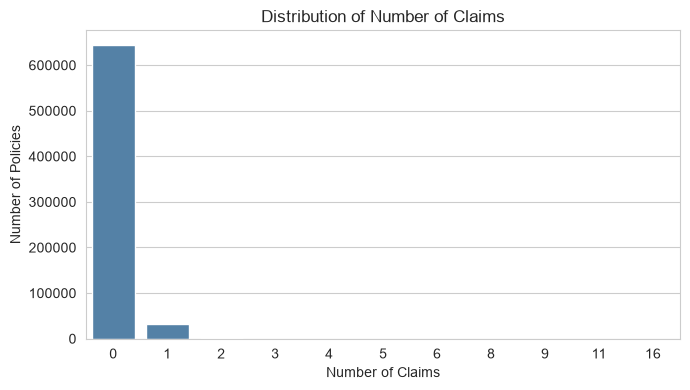

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="ClaimNb", color="steelblue")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")
plt.title("Distribution of Number of Claims", fontsize=12)
plt.tight_layout()
plt.show()

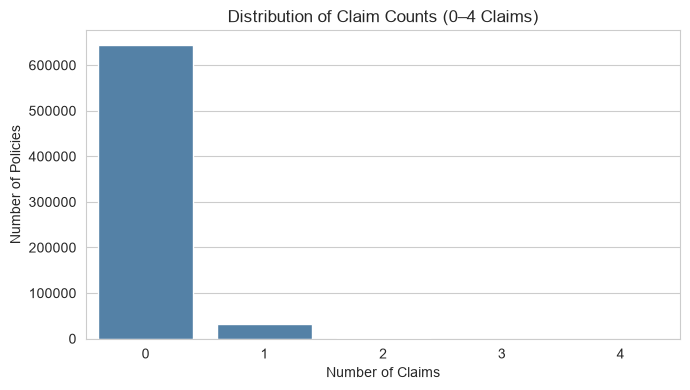

In [12]:
df_common = df[df["ClaimNb"] <= 4]

plt.figure(figsize=(7, 4))
sns.countplot(data=df_common, x="ClaimNb", color="steelblue")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")
plt.title("Distribution of Claim Counts (0–4 Claims)", fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
df[df["ClaimNb"] >= 5][
    ["IDpol", "ClaimNb", "Exposure", "Area", "Region"]
].sort_values("ClaimNb", ascending=False).head(10)

,IDpol,ClaimNb,Exposure,Area,Region
321248,2241683.0,16,0.33,D,R91
6539,19471.0,11,1.00,A,R24
487268,3253234.0,11,0.08,D,R91
488270,3254353.0,11,0.07,D,R91
321512,2248174.0,9,0.08,D,R91
320764,2239279.0,8,0.41,D,R91
304484,2216294.0,6,0.33,D,R91
46470,93954.0,5,1.00,E,R93
344616,2277762.0,5,0.08,D,R91


Most policies have zero claims (about 95%), and policies with several claims are rare. The usual IQR rule is not very useful here because the claim-count quartiles are all zero, so the high counts are inspected directly and kept in the data.

#### Exposure

In [14]:
df["Exposure"].describe()

count    678013.000000
mean          0.528750
std           0.364442
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           2.010000
Name: Exposure, dtype: float64

In [15]:
df[df["Exposure"] > 1]["Exposure"].describe()

count    1224.000000
mean        1.113840
std         0.159296
min         1.010000
25%         1.020000
50%         1.040000
75%         1.150000
max         2.010000
Name: Exposure, dtype: float64

In [16]:
df[df["Exposure"] > 1].head(10)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
179652,1179653.0,0,1.99,A,11,10,50,50,B12,Regular,29,R25
179653,1179654.0,1,1.17,D,4,2,21,112,B6,Regular,721,R93
179655,1179656.0,1,1.12,E,6,0,37,72,B4,Diesel,9307,R82
179657,1179658.0,0,1.48,D,7,4,46,50,B6,Diesel,776,R93
179659,1179660.0,1,1.50,C,8,14,26,76,B1,Regular,372,R25
179660,1179661.0,0,1.53,A,8,16,31,68,B1,Diesel,10,R24
179661,1179662.0,0,1.48,F,5,1,72,50,B14,Regular,27000,R11
179662,1179663.0,0,1.01,B,6,0,24,72,B3,Diesel,93,R91
179665,1179666.0,0,1.03,C,7,4,52,57,B1,Diesel,443,R73
179666,1179667.0,0,1.09,A,5,4,37,50,B4,Diesel,26,R24


In [17]:
df.sort_values("Exposure", ascending=False)[
    ["IDpol", "ClaimNb", "Exposure"]
].head(20)

,IDpol,ClaimNb,Exposure
198847,1198848.0,0,2.01
198144,1198145.0,0,2.01
198478,1198479.0,1,2.00
179652,1179653.0,0,1.99
197024,1197025.0,0,1.98
198423,1198424.0,0,1.93
198899,1198900.0,1,1.92
198823,1198824.0,0,1.90
198945,1198946.0,0,1.90
198654,1198655.0,0,1.88


In [18]:
(df["Exposure"] > 1).mean() * 100

np.float64(0.18052751200935677)

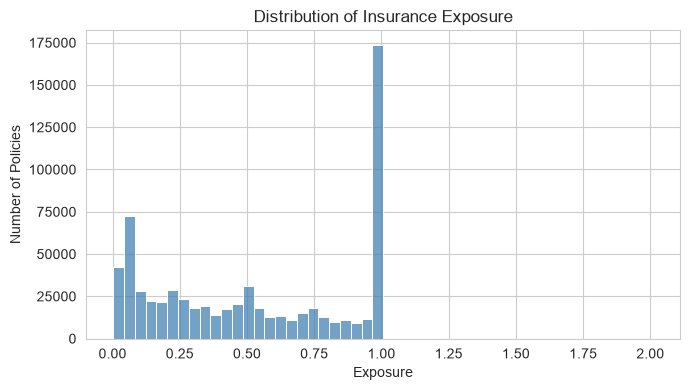

In [19]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Exposure"], bins=50, color="steelblue")
plt.xlabel("Exposure")
plt.ylabel("Number of Policies")
plt.title("Distribution of Insurance Exposure", fontsize=12)
plt.tight_layout()
plt.show()

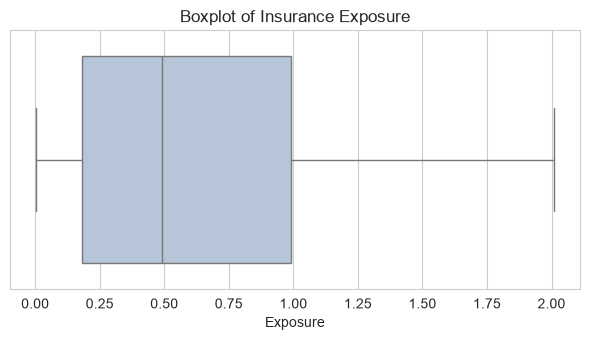

In [20]:
plt.figure(figsize=(6, 3.5))
sns.boxplot(x=df["Exposure"], color="lightsteelblue")
plt.xlabel("Exposure")
plt.title("Boxplot of Insurance Exposure", fontsize=12)
plt.tight_layout()
plt.show()

Most exposure values are at or below 1. Only a small percentage are above 1, and these are kept because they are unusual values rather than confirmed errors.

#### Vehicle Age

In [21]:
df["VehAge"].describe()

count    678013.000000
mean          7.044265
std           5.666232
min           0.000000
25%           2.000000
50%           6.000000
75%          11.000000
max         100.000000
Name: VehAge, dtype: float64

In [22]:
df["VehAge"].value_counts().sort_index()

VehAge
0      57739
1      71284
2      59124
3      50261
4      43492
       ...  
83         2
84         1
85         1
99        23
100       25
Name: count, Length: 78, dtype: int64

In [23]:
df[df["VehAge"] > 30]["VehAge"].value_counts().sort_index()

VehAge
31     217
32     153
33     124
34     103
35      94
36      71
37      47
38      36
39      25
40      16
41       8
42      13
43      15
44      15
45      12
46      19
47      14
48      17
49      12
50       8
51       4
52       6
53       2
54       2
55       1
59       2
60       1
62       1
63       1
64       1
65       2
66       2
68       2
69       4
70       3
71       1
76       1
78       1
79       1
80       3
81       3
82       1
83       2
84       1
85       1
99      23
100     25
Name: count, dtype: int64

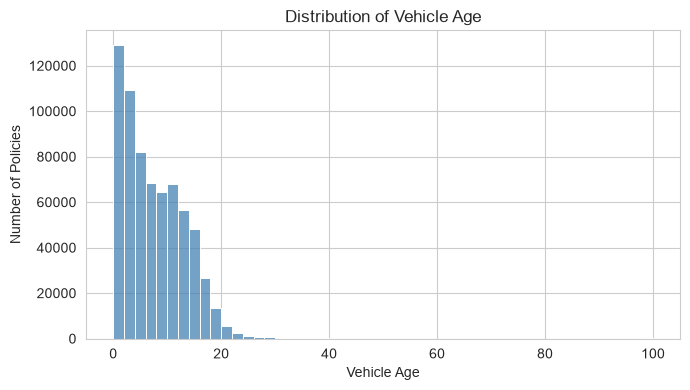

In [24]:
plt.figure(figsize=(7, 4))
sns.histplot(df["VehAge"], bins=50, color="steelblue")
plt.xlabel("Vehicle Age")
plt.ylabel("Number of Policies")
plt.title("Distribution of Vehicle Age", fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
(df["VehAge"] > 30).sum()


np.int64(1116)

In [26]:
(df["VehAge"] > 30).mean() * 100

np.float64(0.1645986138908841)

In [27]:
df[df["VehAge"] >= 50]["VehAge"].value_counts().sort_index()

VehAge
50      8
51      4
52      6
53      2
54      2
55      1
59      2
60      1
62      1
63      1
64      1
65      2
66      2
68      2
69      4
70      3
71      1
76      1
78      1
79      1
80      3
81      3
82      1
83      2
84      1
85      1
99     23
100    25
Name: count, dtype: int64

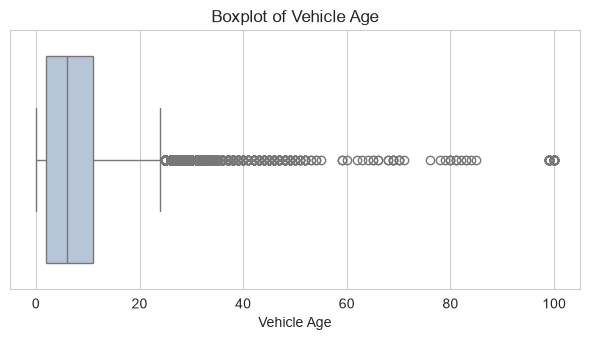

In [28]:
plt.figure(figsize=(6, 3.5))
sns.boxplot(x=df["VehAge"], color="lightsteelblue")
plt.xlabel("Vehicle Age")
plt.title("Boxplot of Vehicle Age", fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
df[df["VehAge"] >= 99][
    ["IDpol", "ClaimNb", "Exposure", "VehAge", "VehBrand"]
].head(20)

,IDpol,ClaimNb,Exposure,VehAge,VehBrand
20638,45432.0,0,0.600000,100,B2
23867,51259.0,0,0.540000,100,B2
26017,55270.0,0,0.120000,100,B1
40103,81023.0,0,0.020000,99,B1
43169,87163.0,0,0.990000,99,B1
43170,87164.0,0,0.005464,99,B1
43179,87183.0,0,0.880000,99,B1
43221,87249.0,0,0.490000,99,B11
43222,87250.0,0,0.250000,99,B11
43271,87350.0,0,0.130000,99,B6


In [30]:
(df["VehAge"] >= 99).sum()

np.int64(48)

Vehicle age is right-skewed, with a small number of very old recorded vehicles. The values 99 and 100 should be checked further, but they are not automatically removed.

#### Driver Age

In [31]:
df["DrivAge"].describe()

count    678013.000000
mean         45.499122
std          14.137444
min          18.000000
25%          34.000000
50%          44.000000
75%          55.000000
max         100.000000
Name: DrivAge, dtype: float64

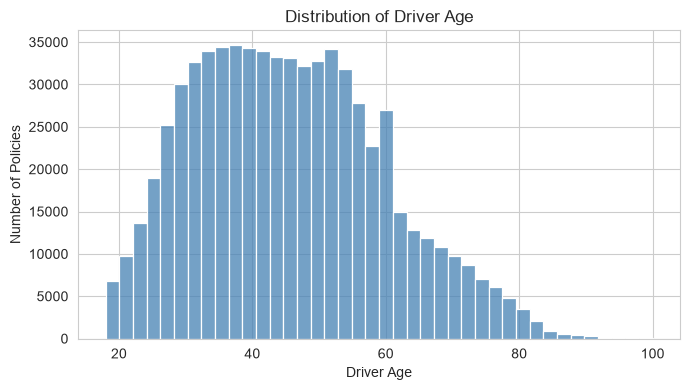

In [32]:
plt.figure(figsize=(7, 4))
sns.histplot(df["DrivAge"], bins=40, color="steelblue")
plt.xlabel("Driver Age")
plt.ylabel("Number of Policies")
plt.title("Distribution of Driver Age", fontsize=12)
plt.tight_layout()
plt.show()

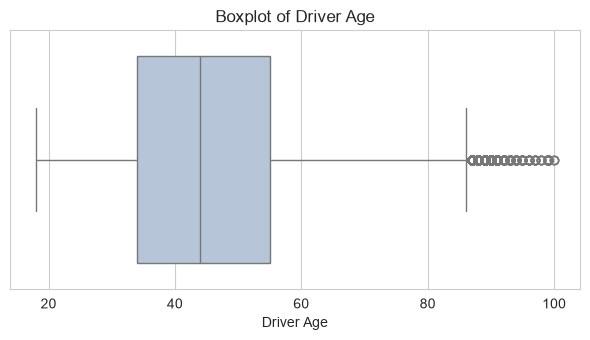

In [33]:
plt.figure(figsize=(6, 3.5))
sns.boxplot(x=df["DrivAge"], color="lightsteelblue")
plt.xlabel("Driver Age")
plt.title("Boxplot of Driver Age", fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
df[df["DrivAge"] >= 80]["DrivAge"].value_counts().sort_index()

DrivAge
80     1925
81     1577
82     1211
83      849
84      578
85      371
86      319
87      280
88      229
89      198
90      167
91      121
92       66
93       55
94       32
95       24
96       15
97       10
98        5
99       70
100       3
Name: count, dtype: int64

Driver age is centred around the middle-age range, with a smaller number of drivers aged 80 or above. These high ages are retained because they may still be valid.

#### Bonus-Malus

In [35]:
df["BonusMalus"].value_counts().sort_index()

BonusMalus
50     384156
51      15869
52       4770
53       3351
54      17360
        ...  
198         2
208         1
218         1
228         1
230         1
Name: count, Length: 115, dtype: int64

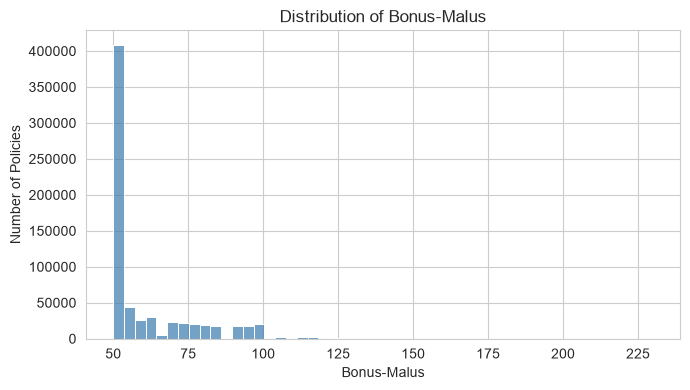

In [36]:
plt.figure(figsize=(7, 4))
sns.histplot(df["BonusMalus"], bins=50, color="steelblue")
plt.xlabel("Bonus-Malus")
plt.ylabel("Number of Policies")
plt.title("Distribution of Bonus-Malus", fontsize=12)
plt.tight_layout()
plt.show()

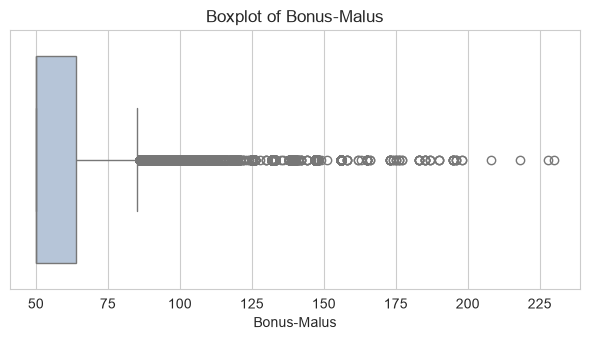

In [37]:
plt.figure(figsize=(6, 3.5))
sns.boxplot(x=df["BonusMalus"], color="lightsteelblue")
plt.xlabel("Bonus-Malus")
plt.title("Boxplot of Bonus-Malus", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
(df["BonusMalus"] > 200).sum()

np.int64(4)

In [39]:
(df["BonusMalus"] > 200).mean() * 100

np.float64(0.0005899591895730613)

In [40]:
df[df["BonusMalus"] > 200]["BonusMalus"].value_counts().sort_index()

BonusMalus
208    1
218    1
228    1
230    1
Name: count, dtype: int64

Bonus-Malus is concentrated near the lower values and has a long right tail. Only four records are above 200, so they should not be changed without further evidence.

#### Population Density

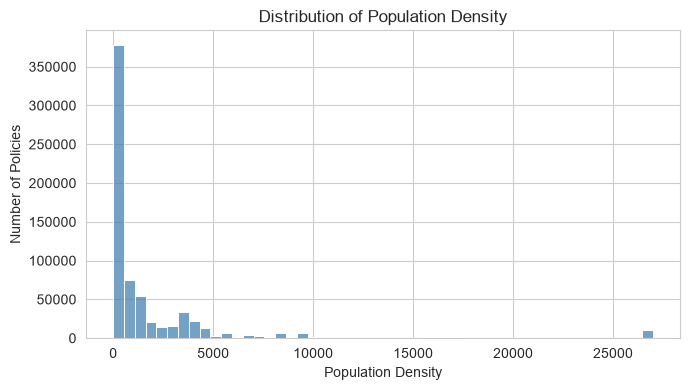

In [41]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Density"], bins=50, color="steelblue")
plt.xlabel("Population Density")
plt.ylabel("Number of Policies")
plt.title("Distribution of Population Density", fontsize=12)
plt.tight_layout()
plt.show()

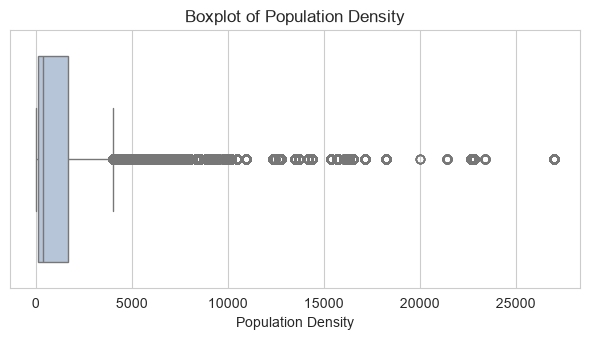

In [42]:
plt.figure(figsize=(6, 3.5))
sns.boxplot(x=df["Density"], color="lightsteelblue")
plt.xlabel("Population Density")
plt.title("Boxplot of Population Density", fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
df[df["Density"] >= 20000]["Density"].value_counts().sort_index()

Density
20000        6
21410       76
22669      463
22821      182
23396       66
27000    10515
Name: count, dtype: int64

In [44]:
(df["Density"] >= 20000).sum()

np.int64(11308)

In [45]:
df[df["Density"] == 27000]["Area"].value_counts()

Area
F    10515
Name: count, dtype: int64

In [46]:
df[df["Density"] == 27000]["Region"].value_counts()

Region
R11    10515
Name: count, dtype: int64

Density is strongly right-skewed. The records with Density 27,000 all belong to Area F and Region R11, which suggests a consistent geographical pattern rather than random data errors.

#### Area

In [47]:
df["Area"].value_counts()

Area
C    191880
D    151596
E    137167
A    103957
B     75459
F     17954
Name: count, dtype: int64

In [48]:
df["Area"].value_counts(normalize=True).sort_index() * 100

Area
A    15.332597
B    11.129433
C    28.300342
D    22.358863
E    20.230733
F     2.648032
Name: proportion, dtype: float64

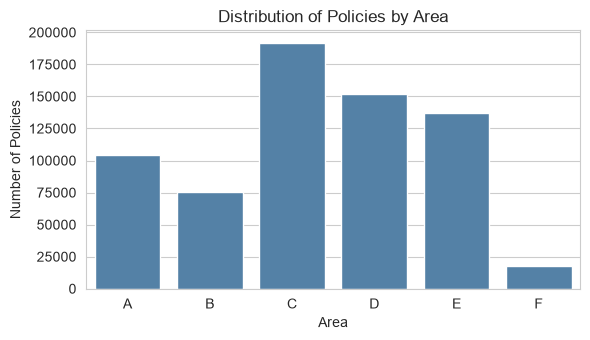

In [49]:
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x="Area", order=sorted(df["Area"].unique()), color="steelblue")
plt.xlabel("Area")
plt.ylabel("Number of Policies")
plt.title("Distribution of Policies by Area", fontsize=12)
plt.tight_layout()
plt.show()

Area C contains the largest number of policies, while Area F contains the fewest. Policy counts alone do not show which area has the highest claim frequency.

#### Vehicle Fuel Type

In [50]:
df["VehGas"].value_counts()

VehGas
Regular    345877
Diesel     332136
Name: count, dtype: int64

In [51]:
df["VehGas"].value_counts(normalize=True) * 100

VehGas
Regular    51.013329
Diesel     48.986671
Name: proportion, dtype: float64

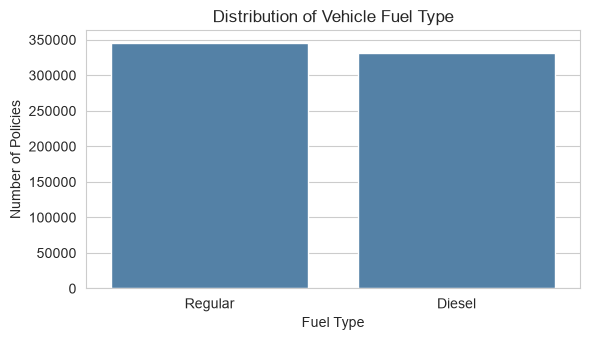

In [52]:
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x="VehGas", color="steelblue")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Policies")
plt.title("Distribution of Vehicle Fuel Type", fontsize=12)
plt.tight_layout()
plt.show()

Diesel and Regular vehicles are both well represented, with slightly more Regular vehicles in the data.

#### Vehicle Brand

In [53]:
df["VehBrand"].value_counts()

VehBrand
B12    166024
B1     162736
B2     159861
B3      53395
B5      34753
B6      28548
B4      25179
B10     17707
B11     13585
B13     12178
B14      4047
Name: count, dtype: int64

In [54]:
df["VehBrand"].value_counts(normalize=True) * 100

VehBrand
B12    24.486846
B1     24.001900
B2     23.577867
B3      7.875218
B5      5.125713
B6      4.210539
B4      3.713646
B10     2.611602
B11     2.003649
B13     1.796131
B14     0.596891
Name: proportion, dtype: float64

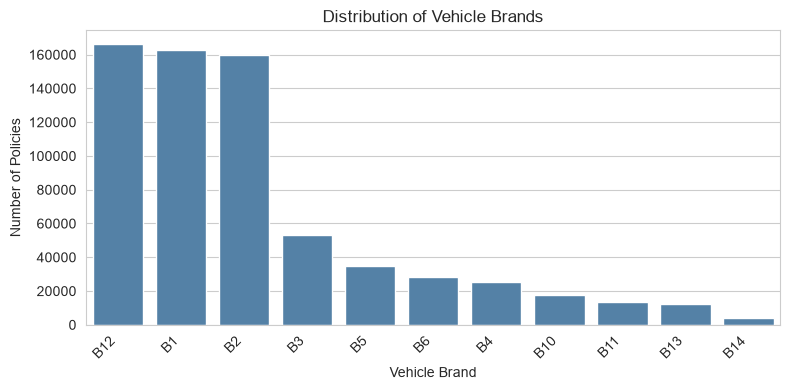

In [55]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="VehBrand",
    order=df["VehBrand"].value_counts().index,
    color="steelblue"
)
plt.xlabel("Vehicle Brand")
plt.ylabel("Number of Policies")
plt.title("Distribution of Vehicle Brands", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Vehicle brand groups have quite different portfolio sizes. A common brand does not necessarily have the highest observed claim frequency.

#### Region

In [56]:
df["Region"].value_counts()

Region
R24    160601
R82     84752
R93     79315
R11     69791
R53     42122
R52     38751
R91     35805
R72     31329
R31     27285
R54     19046
R73     17141
R41     12990
R25     10893
R26     10492
R23      8784
R22      7994
R83      5287
R74      4567
R94      4516
R21      3026
R42      2200
R43      1326
Name: count, dtype: int64

In [57]:
df["Region"].value_counts(normalize=True) * 100

Region
R24    23.687009
R82    12.500055
R93    11.698153
R11    10.293460
R53     6.212565
R52     5.715377
R91     5.280872
R72     4.620708
R31     4.024259
R54     2.809091
R73     2.528123
R41     1.915892
R25     1.606606
R26     1.547463
R23     1.295550
R22     1.179033
R83     0.779779
R74     0.673586
R94     0.666064
R21     0.446304
R42     0.324478
R43     0.195571
Name: proportion, dtype: float64

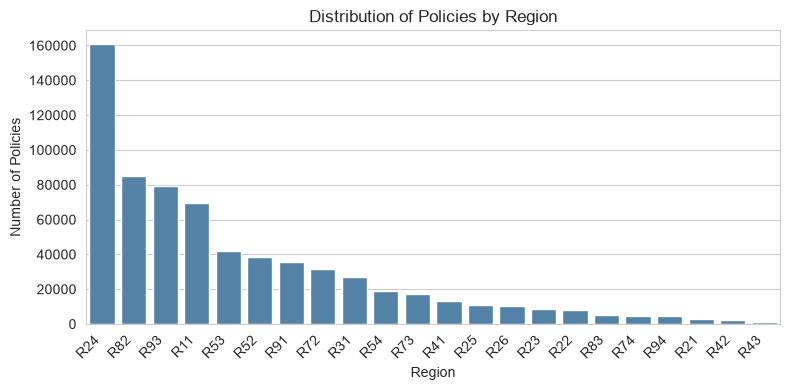

In [58]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="Region",
    order=df["Region"].value_counts().index,
    color="steelblue"
)
plt.xlabel("Region")
plt.ylabel("Number of Policies")
plt.title("Distribution of Policies by Region", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The number of policies differs considerably across regions. Smaller regions need more care when their claim frequencies are compared.

#### Vehicle Power

In [59]:
df["VehPower"].value_counts().sort_index()

VehPower
4     115349
5     124821
6     148976
7     145401
8      46956
9      30085
10     31354
11     18352
12      8214
13      3229
14      2350
15      2926
Name: count, dtype: int64

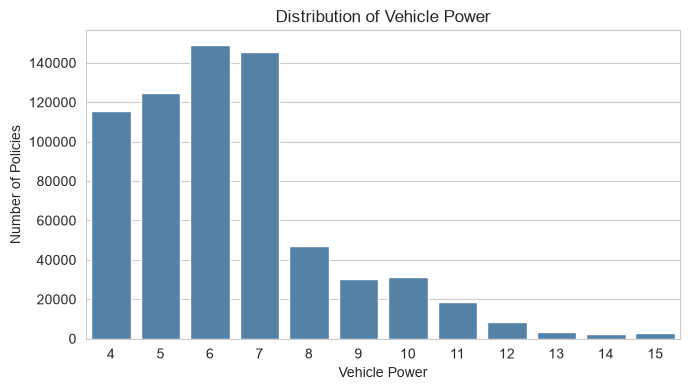

In [60]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x="VehPower",
    order=sorted(df["VehPower"].unique()),
    color="steelblue"
)
plt.xlabel("Vehicle Power")
plt.ylabel("Number of Policies")
plt.title("Distribution of Vehicle Power", fontsize=12)
plt.tight_layout()
plt.show()

Most policies are in the lower and middle vehicle-power categories, especially levels 4 to 7.

### 3.5 Descriptive Relationships with Claim Frequency

Observed claim frequency is calculated as `Total_Claims / Total_Exposure`. This is more useful than comparing raw claims because the groups have different amounts of exposure.

#### Claim Frequency by Area

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
Area,,,,
A,103957,5063,61969.38,0.0817
B,75459,3800,43012.32,0.0883
C,191880,9875,104449.00,0.0945
D,151596,8428,77120.19,0.1093
E,137167,7805,63819.31,0.1223
F,17954,1131,8129.23,0.1391


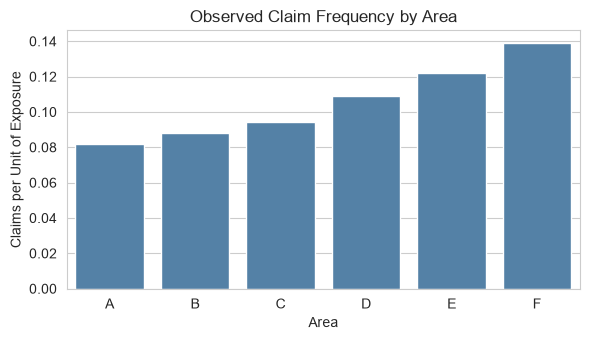

In [61]:
area_summary = df.groupby("Area").agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)

area_summary["Claim_Frequency"] = (
    area_summary["Total_Claims"] / area_summary["Total_Exposure"]
)

display(area_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(6, 3.5))
sns.barplot(x=area_summary.index, y=area_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Area")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Area", fontsize=12)
plt.tight_layout()
plt.show()

Claim frequency appears to increase from Area A to Area F. This suggests Area may be useful when studying differences in insurance risk, but it does not show that Area causes claims.

#### Claim Frequency by Vehicle Fuel Type

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
VehGas,,,,
Diesel,332136,16648,170660.89,0.0976
Regular,345877,19454,187838.55,0.1036


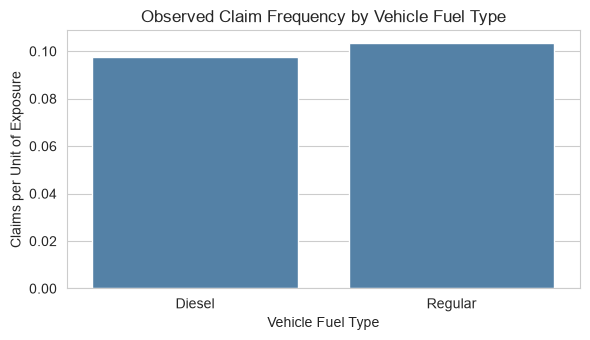

In [62]:
fuel_summary = df.groupby("VehGas").agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
fuel_summary["Claim_Frequency"] = fuel_summary["Total_Claims"] / fuel_summary["Total_Exposure"]
display(fuel_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(6, 3.5))
sns.barplot(x=fuel_summary.index, y=fuel_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Vehicle Fuel Type")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Vehicle Fuel Type", fontsize=12)
plt.tight_layout()
plt.show()

Regular vehicles have a slightly higher observed claim frequency than Diesel vehicles, but the difference is small. No conclusion about statistical significance is made here.

#### Claim Frequency by Vehicle Brand

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
VehBrand,,,,
B14,4047,166,2274.47,0.0730
B2,159861,8560,94864.06,0.0902
B10,17707,858,9496.01,0.0904
B1,162736,8677,95351.06,0.0910
B6,28548,1462,15684.95,0.0932
B4,25179,1312,13775.50,0.0952
B13,12178,649,6772.03,0.0958
B3,53395,2818,28592.88,0.0986
B5,34753,2020,19992.06,0.1010


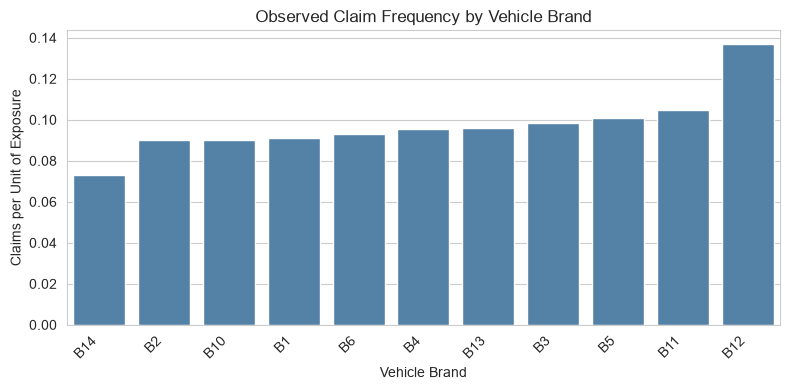

In [63]:
brand_summary = df.groupby("VehBrand").agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
brand_summary["Claim_Frequency"] = brand_summary["Total_Claims"] / brand_summary["Total_Exposure"]
brand_summary = brand_summary.sort_values("Claim_Frequency")
display(brand_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(8, 4))
sns.barplot(x=brand_summary.index, y=brand_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Vehicle Brand")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Vehicle Brand", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observed claim frequency differs across vehicle brands. Portfolio size and claim frequency are different, so the most common brand is not automatically the highest-risk group.

#### Claim Frequency by Region

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
Region,,,,
R41,12990,611,8113.78,0.0753
R83,5287,189,2322.88,0.0814
R54,19046,968,11163.41,0.0867
R24,160601,9204,102712.90,0.0896
R52,38751,2010,21934.03,0.0916
R72,31329,1348,14322.17,0.0941
R25,10893,633,6657.90,0.0951
R23,8784,303,3177.68,0.0954
R53,42122,2702,27753.46,0.0974


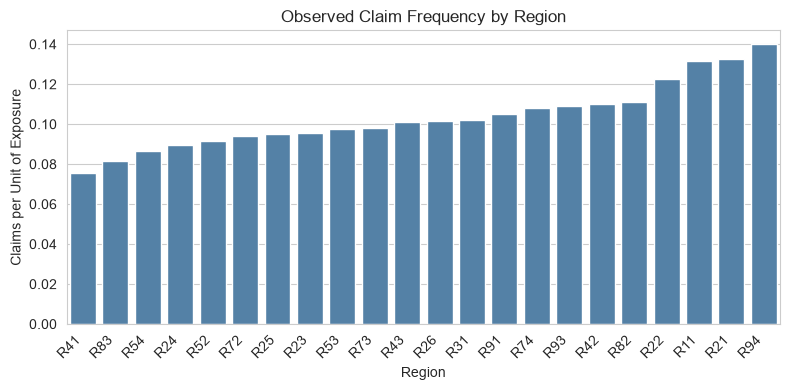

In [64]:
region_summary = df.groupby("Region").agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
region_summary["Claim_Frequency"] = region_summary["Total_Claims"] / region_summary["Total_Exposure"]
region_summary = region_summary.sort_values("Claim_Frequency")
display(region_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(8, 4))
sns.barplot(x=region_summary.index, y=region_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Region")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Region", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observed claim frequency varies between regions. Some regions have much less exposure, so their values should be interpreted carefully.

#### Claim Frequency by Vehicle Power

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
VehPower,,,,
4,115349,5699,60073.64,0.0949
5,124821,7278,68173.35,0.1068
6,148976,8381,82524.21,0.1016
7,145401,7627,77950.46,0.0978
8,46956,1922,22684.62,0.0847
9,30085,1754,15348.21,0.1143
10,31354,1789,15375.01,0.1164
11,18352,897,8497.78,0.1056
12,8214,359,3792.04,0.0947


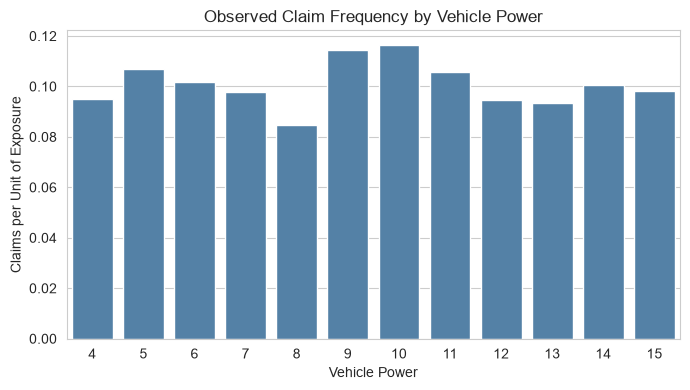

In [65]:
power_summary = df.groupby("VehPower").agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
power_summary["Claim_Frequency"] = power_summary["Total_Claims"] / power_summary["Total_Exposure"]
display(power_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(7, 4))
sns.barplot(x=power_summary.index, y=power_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Vehicle Power")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Vehicle Power", fontsize=12)
plt.tight_layout()
plt.show()

Vehicle power does not show a simple increasing or decreasing pattern in observed claim frequency.

#### Claim Frequency by Driver Age

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
DrivAge,,,,
18-24,30198,2364,12489.16,0.1893
25-34,140947,6396,64598.61,0.0990
35-44,170578,8145,87391.45,0.0932
45-54,164034,9513,89852.75,0.1059
55-64,99094,5124,56176.95,0.0912
65-74,50821,2986,32207.19,0.0927
75+,22341,1574,15783.33,0.0997


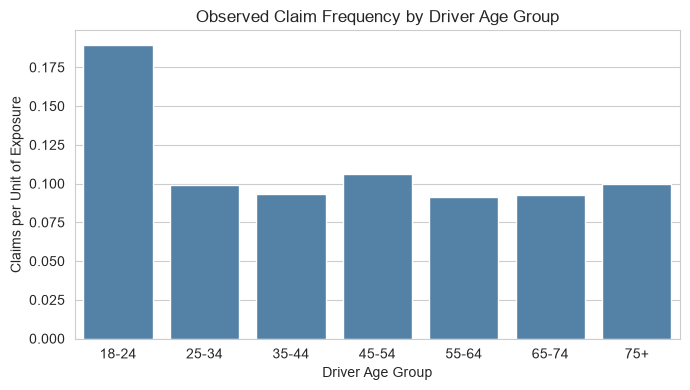

In [66]:
age_bins = [18, 25, 35, 45, 55, 65, 75, 101]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]

driver_age_group = pd.cut(
    df["DrivAge"], bins=age_bins, labels=age_labels, right=False
)

driver_age_summary = df.groupby(driver_age_group, observed=False).agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
driver_age_summary["Claim_Frequency"] = (
    driver_age_summary["Total_Claims"] / driver_age_summary["Total_Exposure"]
)
display(driver_age_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(7, 4))
sns.barplot(x=driver_age_summary.index, y=driver_age_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Driver Age Group")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Driver Age Group", fontsize=12)
plt.tight_layout()
plt.show()

The 18–24 age group has a noticeably higher observed claim frequency than the other groups. This is a descriptive pattern and does not show that age alone causes the difference.

#### Claim Frequency by Vehicle Age

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
VehAge,,,,
0-2,188147,10904,79176.06,0.1377
3-5,132490,6743,72040.12,0.0936
6-10,171594,9846,99008.92,0.0994
11-15,134063,6648,77990.98,0.0852
16-20,43397,1685,25136.16,0.0670
21-30,7206,247,4422.69,0.0558
31+,1116,29,724.52,0.0400


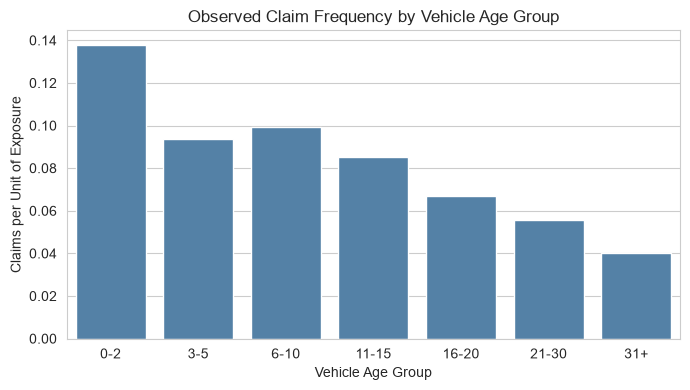

In [67]:
veh_age_bins = [0, 3, 6, 11, 16, 21, 31, 101]
veh_age_labels = ["0-2", "3-5", "6-10", "11-15", "16-20", "21-30", "31+"]

vehicle_age_group = pd.cut(
    df["VehAge"], bins=veh_age_bins, labels=veh_age_labels, right=False
)

vehicle_age_summary = df.groupby(vehicle_age_group, observed=False).agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
vehicle_age_summary["Claim_Frequency"] = (
    vehicle_age_summary["Total_Claims"] / vehicle_age_summary["Total_Exposure"]
)
display(vehicle_age_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(7, 4))
sns.barplot(x=vehicle_age_summary.index, y=vehicle_age_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Vehicle Age Group")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Vehicle Age Group", fontsize=12)
plt.tight_layout()
plt.show()

Newer vehicles have the highest observed claim frequency, and the values are generally lower for older vehicle groups. The 31+ group is much smaller than the main groups, so it should be treated carefully.

#### Claim Frequency by Bonus-Malus

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
BonusMalus,,,,
50-59,461239,21854,265064.65,0.0824
60-69,73179,4326,34161.97,0.1266
70-79,44853,2594,19642.92,0.1321
80-99,71418,4265,29817.70,0.1430
100-149,27115,3009,9717.06,0.3097
150-200,205,52,94.34,0.5512
201+,4,2,0.79,2.5316


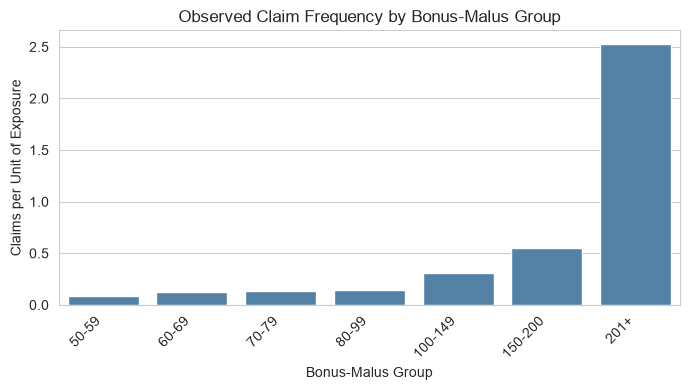

In [68]:
bonus_bins = [50, 60, 70, 80, 100, 150, 201, 231]
bonus_labels = ["50-59", "60-69", "70-79", "80-99", "100-149", "150-200", "201+"]

bonus_group = pd.cut(
    df["BonusMalus"], bins=bonus_bins, labels=bonus_labels, right=False
)

bonus_summary = df.groupby(bonus_group, observed=False).agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
bonus_summary["Claim_Frequency"] = bonus_summary["Total_Claims"] / bonus_summary["Total_Exposure"]
display(bonus_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(7, 4))
sns.barplot(x=bonus_summary.index, y=bonus_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Bonus-Malus Group")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Bonus-Malus Group", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observed claim frequency increases across the Bonus-Malus groups. The 150–200 group is small and the 201+ group has only four policies, so the very high values in these groups should not be over-interpreted.

#### Claim Frequency by Population Density

,Policies,Total_Claims,Total_Exposure,Claim_Frequency
Density,,,,
Low Density,169973,8389,99733.99,0.0841
Medium-Low Density,170244,8572,92281.94,0.0929
Medium-High Density,168456,9311,87962.08,0.1059
High Density,169340,9830,78521.44,0.1252


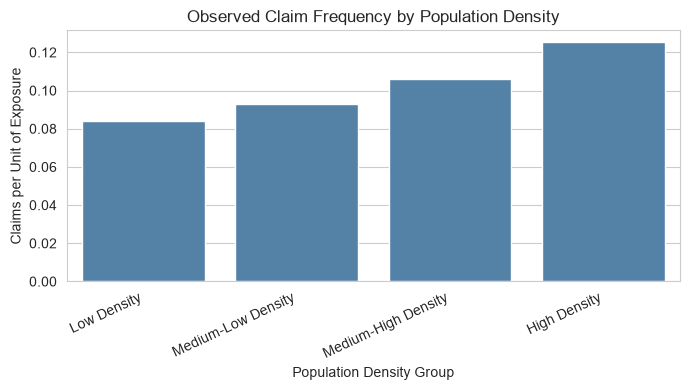

In [69]:
density_group = pd.qcut(
    df["Density"],
    q=4,
    labels=["Low Density", "Medium-Low Density", "Medium-High Density", "High Density"]
)

density_summary = df.groupby(density_group, observed=False).agg(
    Policies=("IDpol", "count"),
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)
density_summary["Claim_Frequency"] = density_summary["Total_Claims"] / density_summary["Total_Exposure"]
display(density_summary.round({"Total_Exposure": 2, "Claim_Frequency": 4}))

plt.figure(figsize=(7, 4))
sns.barplot(x=density_summary.index, y=density_summary["Claim_Frequency"], color="steelblue")
plt.xlabel("Population Density Group")
plt.ylabel("Claims per Unit of Exposure")
plt.title("Observed Claim Frequency by Population Density", fontsize=12)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Observed claim frequency increases from the low-density group to the high-density group. Area and Density may contain related geographical information, so this does not mean Density causes claims.

### 3.6 Initial Business Insights

- Most policies have zero claims, so claims are concentrated in a small part of the portfolio.
- Claim frequency increases from Area A to Area F, which may help with geographical risk grouping.
- Drivers aged 18–24 have the highest observed claim frequency and may need closer portfolio monitoring.
- Newer vehicles show higher observed claim frequency than most older vehicle groups.
- Bonus-Malus has a strong descriptive relationship with claim frequency, although its highest groups are very small.
- Higher-density groups have higher observed claim frequency, but Density may overlap with Area and Region.
- Fuel type shows only a small difference, while vehicle power has no simple clear trend.

These results are exploratory and descriptive. Further statistical work would be needed before making firm management decisions.

In [70]:
assert df.equals(df_raw)
print("The original data have not been changed.")

The original data have not been changed.
